# ***Proyecto ABP 4:* Análisis Exploratorio de Datos para Decisiones Comerciales**

**Autora:** Bernardita Ortega

**Fuente de Base de Datos:** E-commerce User Behavior and Transaction Data
https://www.kaggle.com/datasets/ziya07/e-commerce-user-behavior-and-transaction-dataset

## **Lección 1 - *Análisis Exploratorio de Datos***

🎯 **Objetivo:** Comprender el propósito del EDA y diferenciarlo del análisis inicial.

In [1]:
# Cargar Bibliotecas:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

- **Generar un dataset para poder analizarlo:**

En este caso se utilizará la base de datos "E-commerce User Behavior and Transaction Data" desde Kaggle.

In [2]:
df = pd.read_csv("ecommerce_user_segmentation.csv", sep=',', encoding='utf-8')
df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold


De acuero a lo indicado en el Kaggle, este conjunto de datos simula datos de transacciones e interacción de clientes de una plataforma de comercio electrónico.

**Descripción de la columna:**
- Customer_ID: identificador único de cada cliente
- Indicadores de Comportamiento de Compra:
  - Recency: Días desde la última compra
  - Frequency: Número de compras en los últimos 6 meses
  - Monetary: Gasto total (USD) en los últimos 6 meses
- Avg_Order_Value: Valor promedio del pedido (USD)
- Indicadores de navegación e interacción:
  - Session_Count: Número de sesiones de navegación
  - Avg_Session_Duration: Duración promedio de la sesión (minutos)
  - Pages_Viewed: Promedio de páginas vistas por sesión
  - Clicks: Total de clics en la plataforma
- Interacción y capacidad de respuesta de compra:
  - Campaign_Response: Binario (1 = respondido, 0 = no)
  - Wishlist_Adds: Número de artículos añadidos a la lista de deseos
  - Cart_Abandon_Rate: Tasa de abandono del carrito o Proporción de carritos abandonados (%)
  - Returns: Número de productos devueltos
- Segment_Label: grupo de clientes asignado según su comportamiento general. Pueder ser: Platinum, Gold, Silver, Copper, Iron.

- **Distinguir variables cuantitativas y categóricas:**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           10000 non-null  object 
 1   Recency               10000 non-null  int64  
 2   Frequency             10000 non-null  int64  
 3   Monetary              10000 non-null  int64  
 4   Avg_Order_Value       10000 non-null  int64  
 5   Session_Count         10000 non-null  int64  
 6   Avg_Session_Duration  10000 non-null  float64
 7   Pages_Viewed          10000 non-null  int64  
 8   Clicks                10000 non-null  int64  
 9   Campaign_Response     10000 non-null  int64  
 10  Wishlist_Adds         10000 non-null  int64  
 11  Cart_Abandon_Rate     10000 non-null  float64
 12  Returns               10000 non-null  int64  
 13  Segment_Label         10000 non-null  object 
dtypes: float64(2), int64(10), object(2)
memory usage: 1.1+ MB


In [4]:
# Cambio de Tipo de Variable
# Ya que 'Campaign_Response' es binaria (1 = respondido, 0 = no)
df['Campaign_Response'] = df['Campaign_Response'].astype('category')
df['Segment_Label'] = df['Segment_Label'].astype('category')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Customer_ID           10000 non-null  object  
 1   Recency               10000 non-null  int64   
 2   Frequency             10000 non-null  int64   
 3   Monetary              10000 non-null  int64   
 4   Avg_Order_Value       10000 non-null  int64   
 5   Session_Count         10000 non-null  int64   
 6   Avg_Session_Duration  10000 non-null  float64 
 7   Pages_Viewed          10000 non-null  int64   
 8   Clicks                10000 non-null  int64   
 9   Campaign_Response     10000 non-null  category
 10  Wishlist_Adds         10000 non-null  int64   
 11  Cart_Abandon_Rate     10000 non-null  float64 
 12  Returns               10000 non-null  int64   
 13  Segment_Label         10000 non-null  category
dtypes: category(2), float64(2), int64(9), object(1)
memory 

In [6]:
# Identificar variables cuantitativas y categóricas:
categorical_cols = df.select_dtypes(include=['object','category']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categóricas:", categorical_cols)
print("\nNuméricas:", numerical_cols)

Categóricas: Index(['Customer_ID', 'Campaign_Response', 'Segment_Label'], dtype='object')

Numéricas: Index(['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Session_Count',
       'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Wishlist_Adds',
       'Cart_Abandon_Rate', 'Returns'],
      dtype='object')


- **Detectar valores faltantes o inconsistencias (IDA):**

In [7]:
# Verificar valores nulos:
df.isnull().sum()

,0
Customer_ID,0
Recency,0
Frequency,0
Monetary,0
Avg_Order_Value,0
Session_Count,0
Avg_Session_Duration,0
Pages_Viewed,0
Clicks,0
Campaign_Response,0


El dataset no cuenta con valores nulos o pérdidos.

In [8]:
#Verificar duplicados:
df.duplicated().sum()

np.int64(0)

El dataset no cuenta con valores duplicados.

- **Documentar primeros hallazgos:**

1. El dataset cuenta con 10.000 filas. Cada una es el registro de compartamiento de un cliente.
2. No cuenta con datos pérdidos/nulos, ni duplicados.
3. Cuenta con 14 columnas cada una asociada a una variable.
4. Las variables se pueden dividir en:
  - Categóricas: 'Customer_ID', 'Campaign_Response', 'Segment_Label'.
  - Cuantitativa: 'Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns'.

## **Lección 2 - *Conceptos Básicos de Estadística Descriptiva***

📌 **Objetivo:** Aplicar conceptos de tendencia central, dispersión y medidas de posición.

1. **Calcular media, mediana, moda, varianza, desviación estándar**

In [9]:
# Existen dos formas de calcular estas:

# A través de .describe() y este entrega un cuadro resumen de varios estadísticos
df[numerical_cols].describe()

,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Wishlist_Adds,Cart_Abandon_Rate,Returns
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.665400,28.783000,1938.394600,146.599900,55.915800,15.444645,33.99840,1211.465100,28.618300,17.653052,7.268800
std,37.818734,23.133669,2327.840348,87.564246,43.551484,8.133285,21.14206,1058.875362,23.544257,10.013803,5.623247
min,1.000000,0.000000,0.000000,10.000000,0.000000,1.000433,1.00000,50.000000,0.000000,0.007050,0.000000
25%,22.000000,10.000000,269.000000,79.000000,22.000000,9.515457,18.00000,451.750000,11.000000,10.829601,3.000000
50%,40.000000,20.000000,1022.000000,135.000000,44.000000,14.305176,30.00000,871.000000,21.000000,15.908491,6.000000
75%,63.000000,40.000000,2825.250000,196.000000,75.000000,19.725305,46.00000,1518.000000,41.000000,22.769516,11.000000
max,179.000000,99.000000,9995.000000,399.000000,199.000000,39.995729,99.00000,4998.000000,99.000000,49.994254,24.000000


In [10]:
# Calcula cada estadístico por columna númerica.

# Estadísticas de Tendencia Central:
# Calculo de Media o Promedio
mean_values = df[numerical_cols].mean()
print("Media:\n",mean_values)

Media:
 Recency                   48.665400
Frequency                 28.783000
Monetary                1938.394600
Avg_Order_Value          146.599900
Session_Count             55.915800
Avg_Session_Duration      15.444645
Pages_Viewed              33.998400
Clicks                  1211.465100
Wishlist_Adds             28.618300
Cart_Abandon_Rate         17.653052
Returns                    7.268800
dtype: float64


In [11]:
# Calculo de Mediana
median_values = df[numerical_cols].median()
print("Mediana:\n", median_values)

Mediana:
 Recency                   40.000000
Frequency                 20.000000
Monetary                1022.000000
Avg_Order_Value          135.000000
Session_Count             44.000000
Avg_Session_Duration      14.305176
Pages_Viewed              30.000000
Clicks                   871.000000
Wishlist_Adds             21.000000
Cart_Abandon_Rate         15.908491
Returns                    6.000000
dtype: float64


In [12]:
# Calculo de Moda
mode_values = df[numerical_cols].mode().iloc[0]
print("Moda:\n", mode_values)

Moda:
 Recency                  29.000000
Frequency                 8.000000
Monetary                 45.000000
Avg_Order_Value         109.000000
Session_Count            18.000000
Avg_Session_Duration      1.000433
Pages_Viewed             21.000000
Clicks                  223.000000
Wishlist_Adds             1.000000
Cart_Abandon_Rate         0.007050
Returns                   4.000000
Name: 0, dtype: float64


In [13]:
# Medidas de dispersión
# Calculo de Rango
range_values = df[numerical_cols].max() - df[numerical_cols].min()
print("Rango: \n", range_values)

Rango: 
 Recency                  178.000000
Frequency                 99.000000
Monetary                9995.000000
Avg_Order_Value          389.000000
Session_Count            199.000000
Avg_Session_Duration      38.995296
Pages_Viewed              98.000000
Clicks                  4948.000000
Wishlist_Adds             99.000000
Cart_Abandon_Rate         49.987204
Returns                   24.000000
dtype: float64


In [14]:
# Calculo de Desviacción Estándar
std_values = df[numerical_cols].std()
print("Desviación estándar: \n", std_values)

Desviación estándar: 
 Recency                   37.818734
Frequency                 23.133669
Monetary                2327.840348
Avg_Order_Value           87.564246
Session_Count             43.551484
Avg_Session_Duration       8.133285
Pages_Viewed              21.142060
Clicks                  1058.875362
Wishlist_Adds             23.544257
Cart_Abandon_Rate         10.013803
Returns                    5.623247
dtype: float64


In [15]:
# Calculo de Varianza
variance_values = df[numerical_cols].var()
print("Varianza: \n", variance_values)

Varianza: 
 Recency                 1.430257e+03
Frequency               5.351666e+02
Monetary                5.418841e+06
Avg_Order_Value         7.667497e+03
Session_Count           1.896732e+03
Avg_Session_Duration    6.615032e+01
Pages_Viewed            4.469867e+02
Clicks                  1.121217e+06
Wishlist_Adds           5.543320e+02
Cart_Abandon_Rate       1.002763e+02
Returns                 3.162091e+01
dtype: float64


2. **Determinar cuartiles y percentiles.**

In [16]:
# Calculo de cuartiles (Q1, Q2, Q3) para todas las variables numéricas
Q1 = df[numerical_cols].quantile(0.25)
Q2 = df[numerical_cols].quantile(0.50)  # Mediana
Q3 = df[numerical_cols].quantile(0.75)

print("Cuartiles (Q1, Q2, Q3):")
print(f"\nQ1:\n{Q1}")
print(f"\nQ2 (Mediana):\n{Q2}")
print(f"\nQ3:\n{Q3}")

Cuartiles (Q1, Q2, Q3):

Q1:
Recency                  22.000000
Frequency                10.000000
Monetary                269.000000
Avg_Order_Value          79.000000
Session_Count            22.000000
Avg_Session_Duration      9.515457
Pages_Viewed             18.000000
Clicks                  451.750000
Wishlist_Adds            11.000000
Cart_Abandon_Rate        10.829601
Returns                   3.000000
Name: 0.25, dtype: float64

Q2 (Mediana):
Recency                   40.000000
Frequency                 20.000000
Monetary                1022.000000
Avg_Order_Value          135.000000
Session_Count             44.000000
Avg_Session_Duration      14.305176
Pages_Viewed              30.000000
Clicks                   871.000000
Wishlist_Adds             21.000000
Cart_Abandon_Rate         15.908491
Returns                    6.000000
Name: 0.5, dtype: float64

Q3:
Recency                   63.000000
Frequency                 40.000000
Monetary                2825.250000
Avg_Order

In [17]:
# Calculo de Percentil Ingresado por Usuario
deseado = int(input("Ingrese el percentil deseado (ej. 90): "))
percentile = df[numerical_cols].quantile(deseado/100)

print("\nPercentil ",deseado,":")
print(percentile)

Ingrese el percentil deseado (ej. 90): 90

Percentil  90 :
Recency                   97.000000
Frequency                 64.000000
Monetary                5141.700000
Avg_Order_Value          275.000000
Session_Count            116.000000
Avg_Session_Duration      27.297387
Pages_Viewed              64.000000
Clicks                  2760.000000
Wishlist_Adds             64.000000
Cart_Abandon_Rate         29.843821
Returns                   15.000000
Name: 0.9, dtype: float64


3. **Generar histogramas y boxplots**

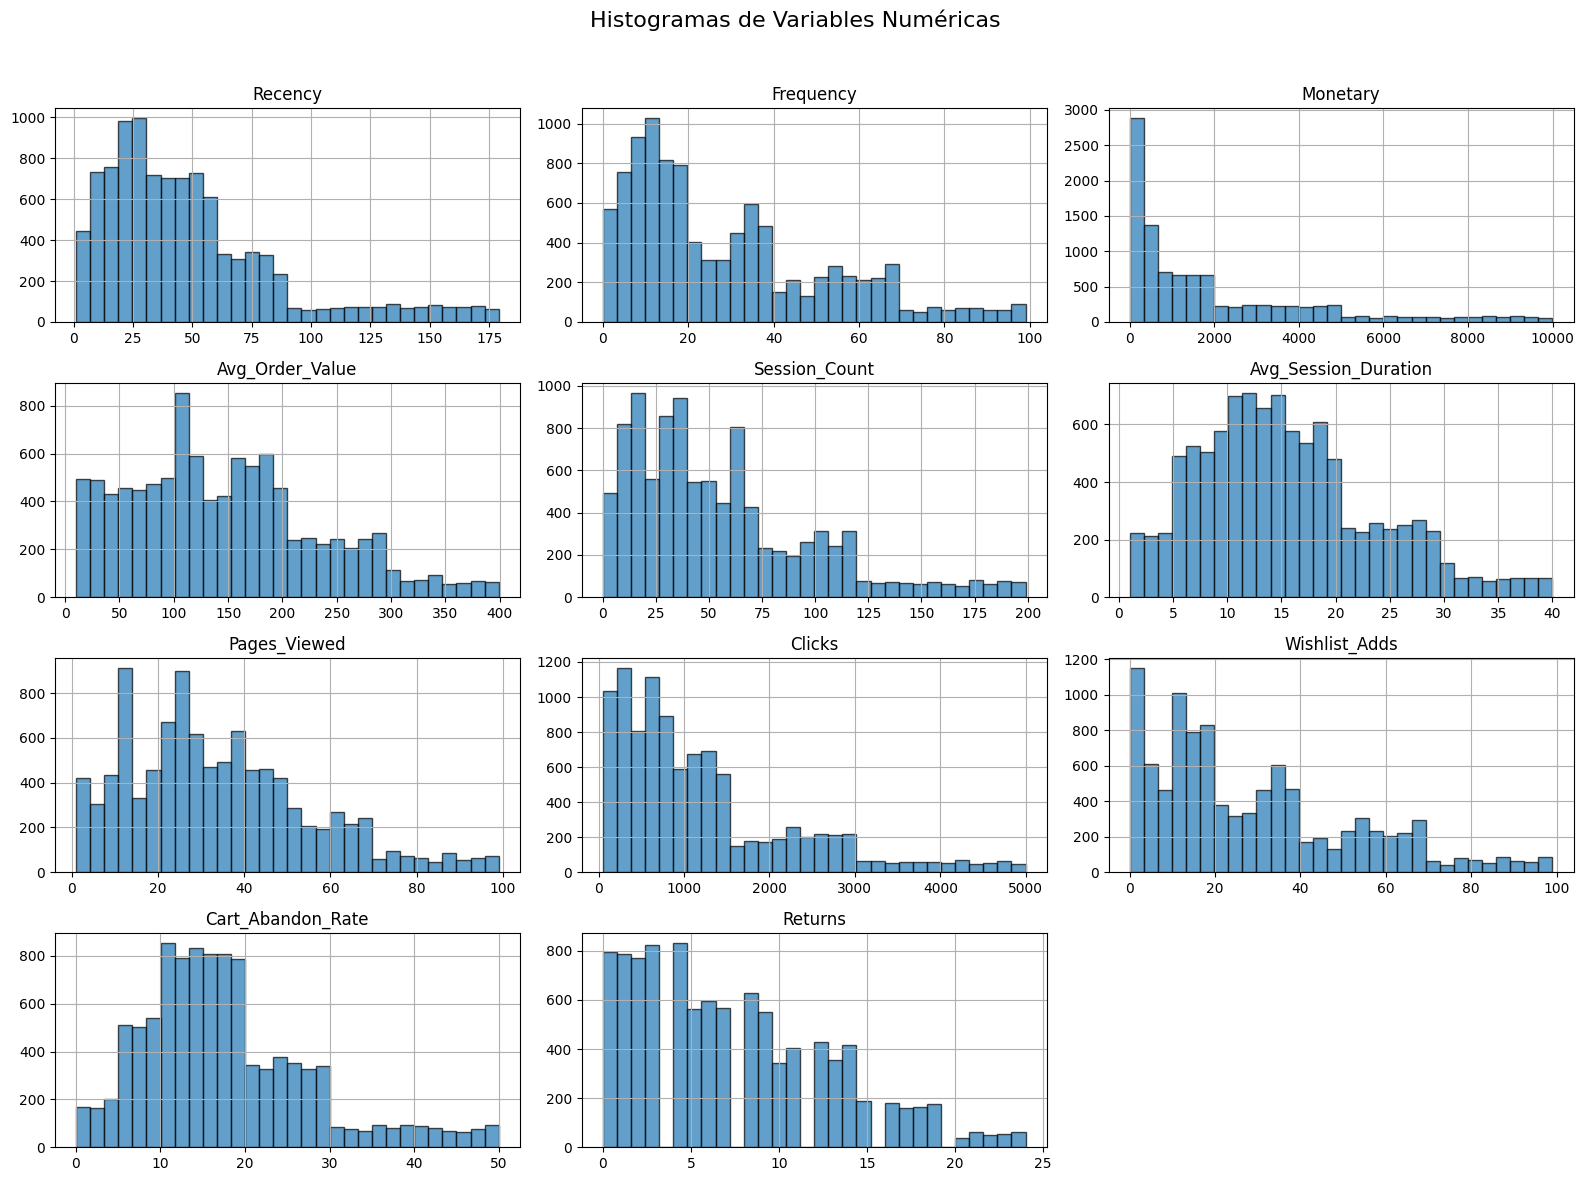

In [18]:
# Histograma
df[numerical_cols].hist(  # Selecciona las 12 variables numéricas y realiza un HISTograma
    bins=30,  # Divide los datos en 30 intervalos
    edgecolor='black', # Agrega borde negro a cada barra
    alpha=0.7, # Transparencia de las columnas
    figsize=(16, 12), # Define el tamaño total de la figura.
    layout=(4, 3) # Controla la organización de la grilla en 4 filas y 3 columnas
)

plt.suptitle('Histogramas de Variables Numéricas', fontsize=16) # Agrega un título general para todos los gráficos
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta automáticamente el espacio entre gráficos
plt.show() # Muestra la figura final.

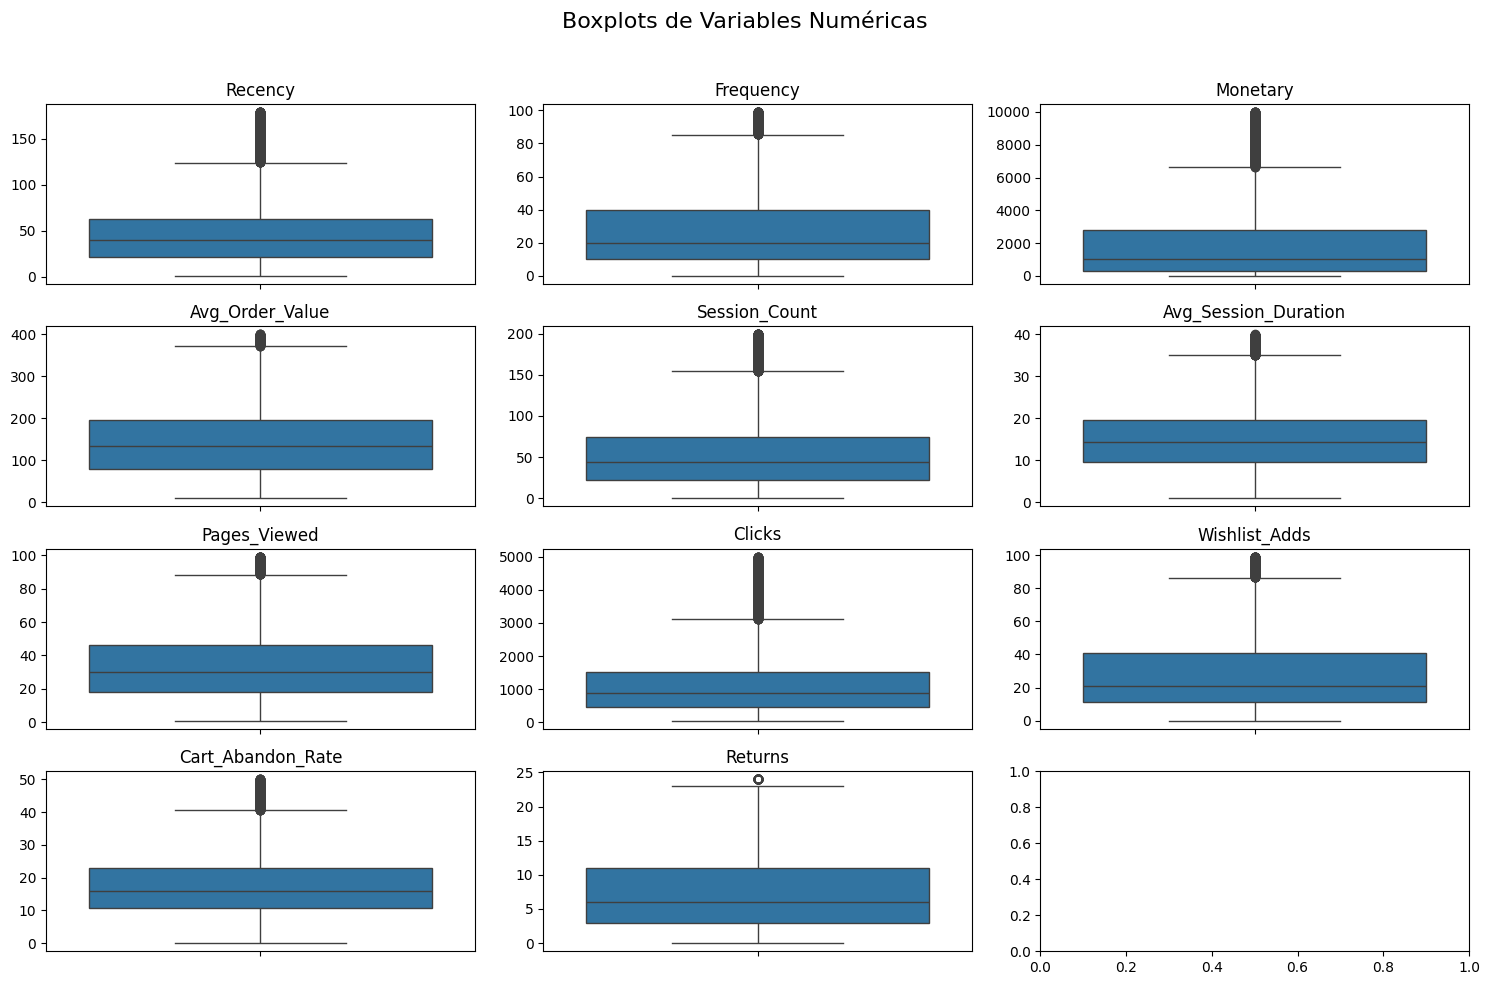

In [19]:
# Boxplot
fig, axes = plt.subplots(4, 3, figsize=(15, 10)) # crea una grilla de 4 filas y 3 columnas
axes = axes.flatten() # convertir la matriz en una lista plana

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i]) # crea un boxplot de la variable actual y lo dibuja en el espacio axes[i]
    axes[i].set_title(col) # agrega título individual del nombre de la variable
    axes[i].set_ylabel('') # elimina la etiqueta del eje Y

fig.suptitle('Boxplots de Variables Numéricas', fontsize=16) # agrega el titulo de la figura
plt.tight_layout(rect=[0, 0, 1, 0.96]) # ajusta automáticamente los espacios entre subplots
plt.show()

4. **Identificar valores atípicos y documentar su impacto**

In [20]:
# IQR (Rango Intercuartílico)

# Calcular Q1 y Q3, y detectar outliers
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Outliers
outliers = (df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))

print("Outliers detectados: \n", outliers.sum())

Outliers detectados: 
 Recency                 683
Frequency               277
Monetary                674
Avg_Order_Value         134
Session_Count           454
Avg_Session_Duration    247
Pages_Viewed            214
Clicks                  634
Wishlist_Adds           271
Cart_Abandon_Rate       437
Returns                  63
dtype: int64


## **Lección 3 - *Correlación***

📌 **Objetivo:** Detectar y cuantificar relaciones entre variables numéricas.

1. **Construir scatterplots y matrices de correlación**

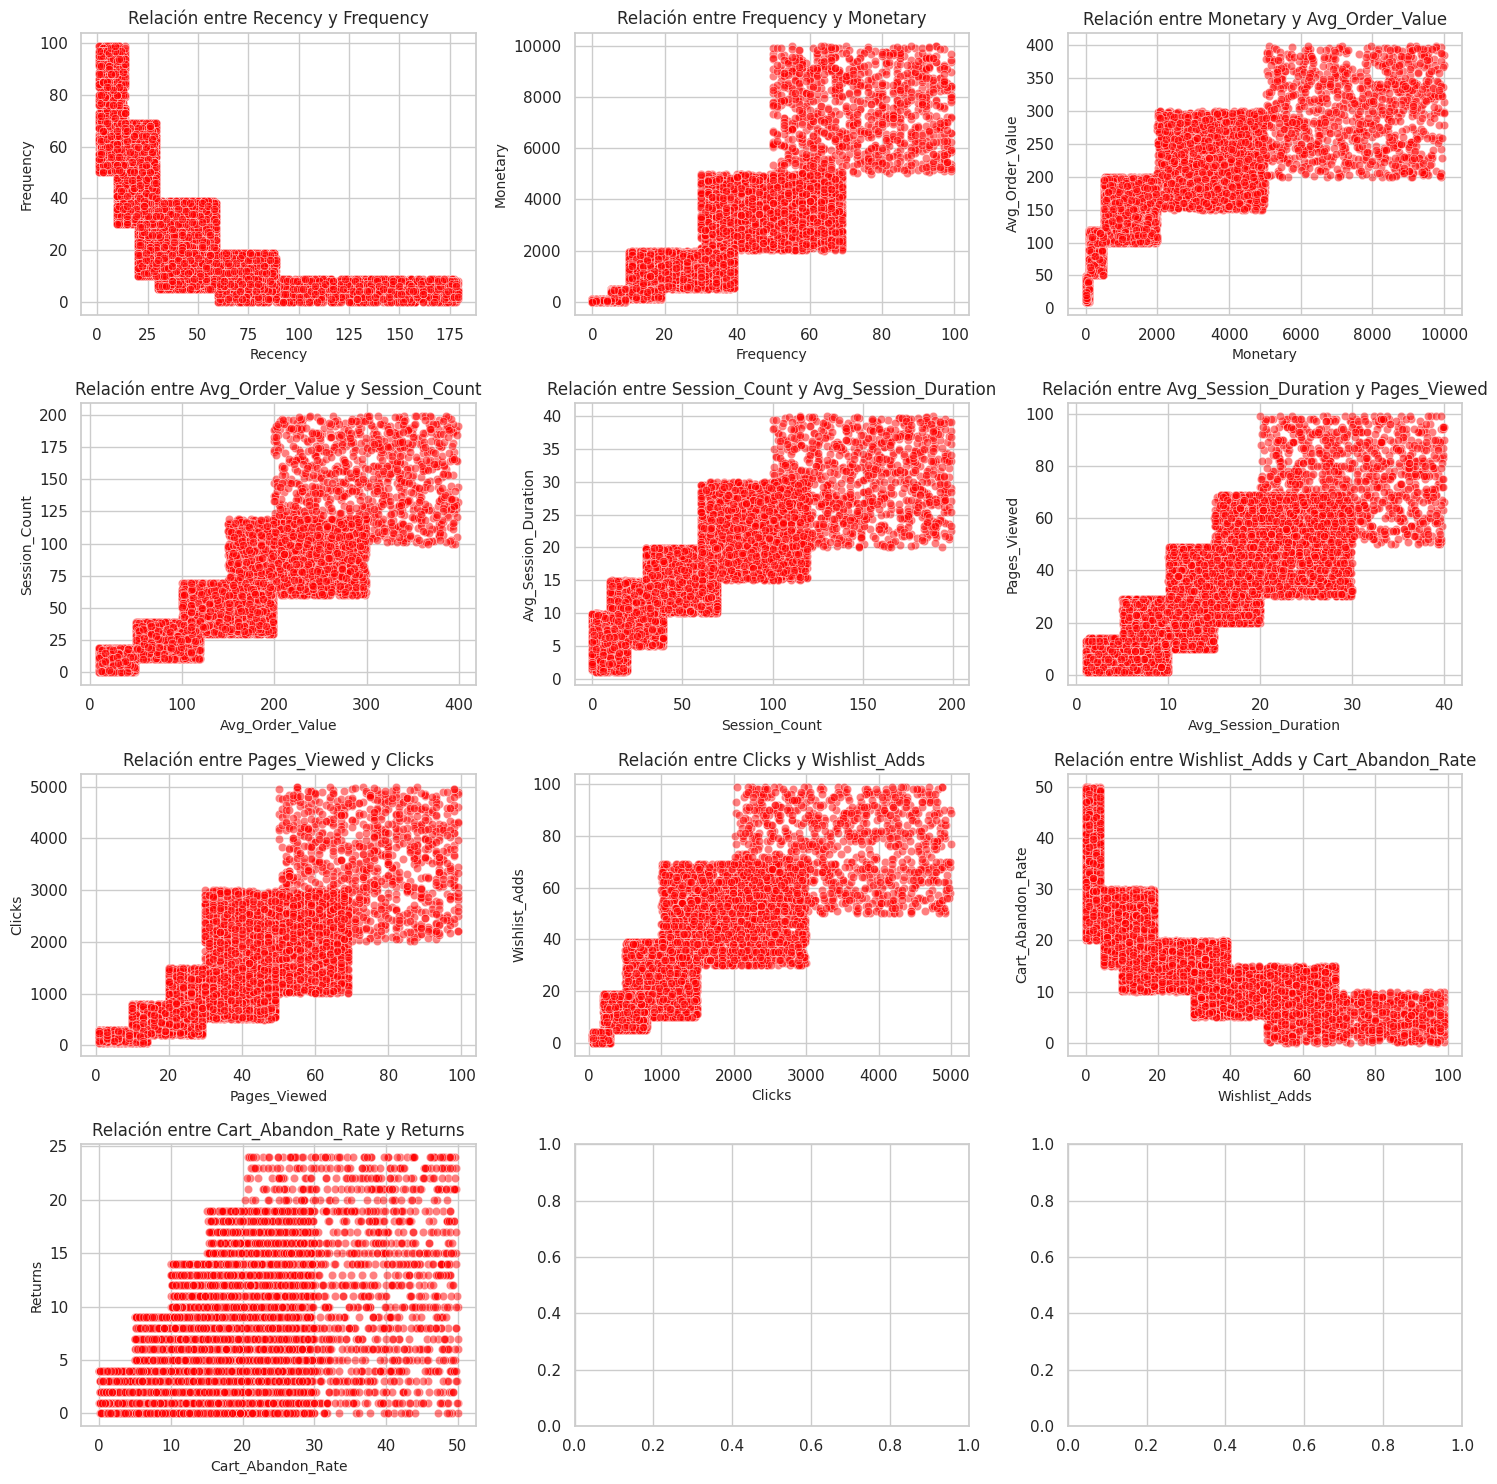

In [21]:
#  Scatterplots
sns.set(style="whitegrid") # Estilo de gráfico
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(numerical_cols) - 1:  # Asegurarse de no exceder el número de columnas
        next_col = numerical_cols[i + 1]
        sns.scatterplot(x=df[col], y=df[next_col], ax=axes[i], color="red", alpha=0.5)
        axes[i].set_title(f"Relación entre {col} y {next_col}", fontsize=12)
        axes[i].set_xlabel(f'{col}', fontsize=10)
        axes[i].set_ylabel(f'{next_col}', fontsize=10)

plt.tight_layout() # Ajustar el espacio entre subgráficos
plt.show() # Muestra la gráfica

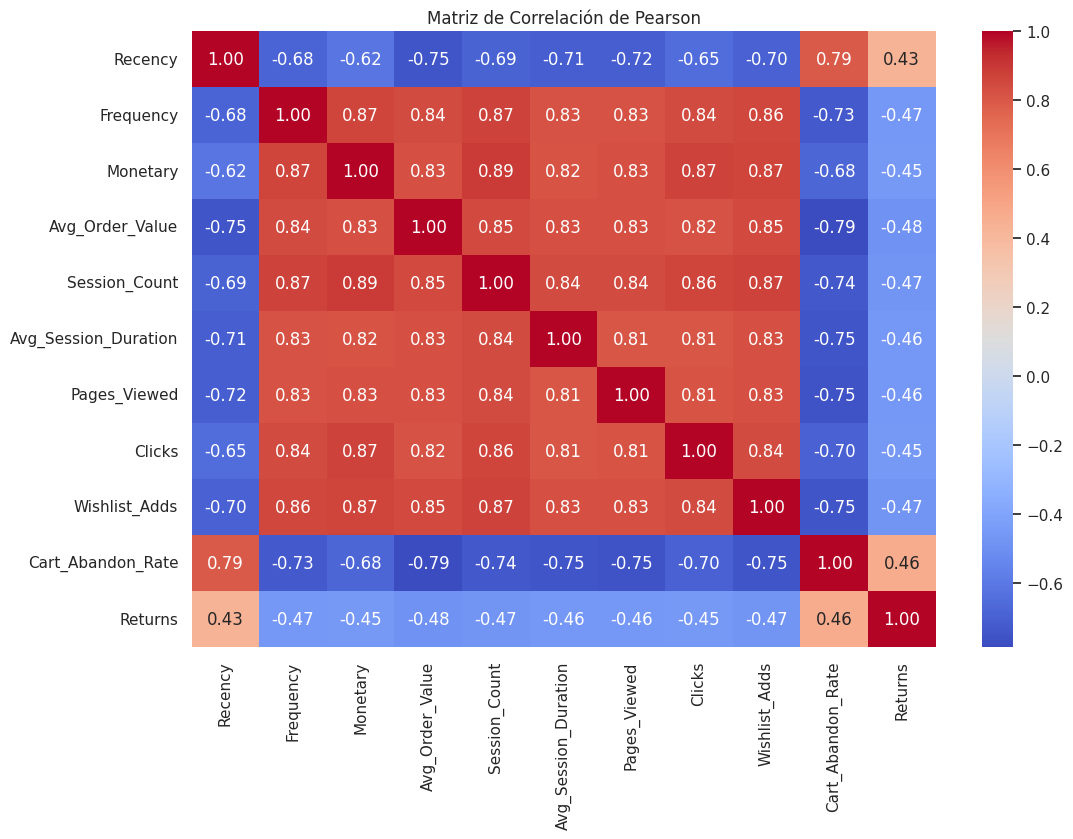

In [22]:
# Matriz de correlación de Pearson
correlation_matrix = df[numerical_cols].corr()

# Visualización de la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Pearson')
plt.show()

2. **Calcular el coeficiente de Pearson (R)**

Los valores anteriores en cada coordenada corresponde al coeficiente de Pearson (R) entre las variables en estudio.

3. **Detectar correlaciones espurias y justificar**

In [23]:
# Primero se debe verificar cuales tienen correlaciones altas
# Umbral para identificar correlaciones altas
threshold = 0.75

# Filtrar y mostrar las correlaciones altas
high_corr = correlation_matrix[(correlation_matrix > threshold) | (correlation_matrix < -threshold)]
high_corr

,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Wishlist_Adds,Cart_Abandon_Rate,Returns
Recency,1.000000,NaN,NaN,-0.750726,NaN,NaN,NaN,NaN,NaN,0.790685,NaN
Frequency,NaN,1.000000,0.865951,0.840384,0.868330,0.825177,0.825185,0.840506,0.855400,NaN,NaN
Monetary,NaN,0.865951,1.000000,0.825762,0.890734,0.817371,0.829674,0.869714,0.867322,NaN,NaN
Avg_Order_Value,-0.750726,0.840384,0.825762,1.000000,0.852121,0.828990,0.831337,0.821327,0.848466,-0.787030,NaN
Session_Count,NaN,0.868330,0.890734,0.852121,1.000000,0.840415,0.840531,0.862768,0.868500,NaN,NaN
Avg_Session_Duration,NaN,0.825177,0.817371,0.828990,0.840415,1.000000,0.807141,0.805106,0.832388,-0.750982,NaN
Pages_Viewed,NaN,0.825185,0.829674,0.831337,0.840531,0.807141,1.000000,0.814695,0.830810,-0.754048,NaN
Clicks,NaN,0.840506,0.869714,0.821327,0.862768,0.805106,0.814695,1.000000,0.843176,NaN,NaN
Wishlist_Adds,NaN,0.855400,0.867322,0.848466,0.868500,0.832388,0.830810,0.843176,1.000000,NaN,NaN
Cart_Abandon_Rate,0.790685,NaN,NaN,-0.787030,NaN,-0.750982,-0.754048,NaN,NaN,1.000000,NaN


In [24]:
# Para comprobar si la relación es espuria,
# se debe controlar la variable confusora mediante correlación parcial
import pingouin as pg

def parcial(x, y, control):
    res = pg.partial_corr(data=df,
                          x=x,
                          y=y,
                          covar=control,
                          method='pearson')
    print(f"\nCorrelación parcial: {x} vs {y} controlando {control}")
    print(res)

# Clicks – Wishlist_Adds
# Confusor posible: Session_Count
parcial('Clicks', 'Wishlist_Adds', 'Session_Count')

# Pages_Viewed – Session_Count
# Confusor posible: Avg_Session_Duration
parcial('Pages_Viewed', 'Session_Count', 'Avg_Session_Duration')

# Session_Count – Avg_Session_Duration
# Confusor posible: Pages_Viewed
parcial('Session_Count', 'Avg_Session_Duration', 'Pages_Viewed')


Correlación parcial: Clicks vs Wishlist_Adds controlando Session_Count
             n         r         CI95%  p-val
pearson  10000  0.374518  [0.36, 0.39]    0.0

Correlación parcial: Pages_Viewed vs Session_Count controlando Avg_Session_Duration
             n         r         CI95%  p-val
pearson  10000  0.506963  [0.49, 0.52]    0.0

Correlación parcial: Session_Count vs Avg_Session_Duration controlando Pages_Viewed
             n         r         CI95%  p-val
pearson  10000  0.506475  [0.49, 0.52]    0.0


In [25]:
!pip install pingouin
import pingouin

**Clasificación de correlaciones (Pearson vs Parcial)**

| Relación                              | R original | r parcial | Clasificación             |
|----------------------------------------|------------|-----------|----------------------------|
| Clicks – Wishlist_Adds                | 0.84       | 0.374     | Parcialmente espuria       |
| Pages_Viewed – Session_Count          | 0.84       | 0.507     | No espuria                 |
| Session_Count – Avg_Session_Duration  | 0.84       | 0.506     | No espuria                 |

No se encontraron correlaciones completamente espurias (ninguna se aproximó a 0).

## **Lección 4 - *Regresiones Lineales***

📌 Objetivo: Implementar un modelo de regresión simple y múltiple para explicar variables dependientes.

1. **Aplicar modelos con statsmodels**

Se utilizará Monetary (Gasto total (USD) en los últimos 6 meses) explicado por Frequency (Número de compras en los últimos 6 meses).

In [26]:
import statsmodels.api as sm

# =========================
# REGRESIÓN SIMPLE: Monetary ~ Frequency
# =========================

# Variable dependiente
y = df['Monetary'] # gasto total

# Variable independiente
X = df[['Frequency']] # número de compras
X = sm.add_constant(X) # agrega constante

# Modelo de regresión lineal simple - Mínimos Cuadrados Ordinarios
modelo_simple = sm.OLS(y, X).fit()

print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:               Monetary   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                 2.997e+04
Date:                Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:23:31   Log-Likelihood:                -84787.
No. Observations:               10000   AIC:                         1.696e+05
Df Residuals:                    9998   BIC:                         1.696e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -569.6655     18.585    -30.651      0.0

El modelo explica el 75% de la variabilidad del gasto total (R-squared = 0.750). Eso es bastante alto para un modelo simple. Significa que Frequency por sí sola explica gran parte del gasto.

Se tiene un p-value = 0.00 (Prob (F-statistic)) → El modelo es estadísticamente significativo. Por lo tanto, la relación entre Frequency y Monetary no es producto del azar.

Este resultado corresponde a:
- Monetary = B0 + B1(Frequency)
- Modelo estimado: Monetary = -569.67 + 87.14(Frequency)

2. **Calcular R², MSE, MAE**

In [38]:
# Predicciones
y_pred = modelo_simple.predict(X)

# Métricas
r2 = modelo_simple.rsquared
mse = np.mean((y - y_pred) ** 2)
mae = np.mean(np.abs(y - y_pred))

print("Métricas del modelo simple:")
print(" R²:", round(r2, 4))
print(" MSE:", round(mse, 4))
print(" MAE:", round(mae, 4))

Métricas del modelo simple:
 R²: 0.7499
 MSE: 1355274.9486
 MAE: 800.29


El modelo o la frecuencia de compra explica el 74.99% de la variabilidad del gasto total.

En promedio, el modelo se equivoca en 800.29 USD por cliente.

3. **Evaluar significancia de predictores**

El predictor Frequency resultó estadísticamente significativo (β = 87.14, t = 173.13, p < 0.001), indicando que existe una relación positiva entre el número de compras y el gasto total.

4. **Interpretar coeficientes e inferencias básicas**

El coeficiente estimado para la variable Frequency (β = 87.14, p < 0.001) sugiere que cada compra adicional se asocia con un incremento promedio de 87.14 unidades monetarias en el gasto total, evidenciando una relación positiva y estadísticamente significativa.

5. **Visualizar la regresión con Seaborn**

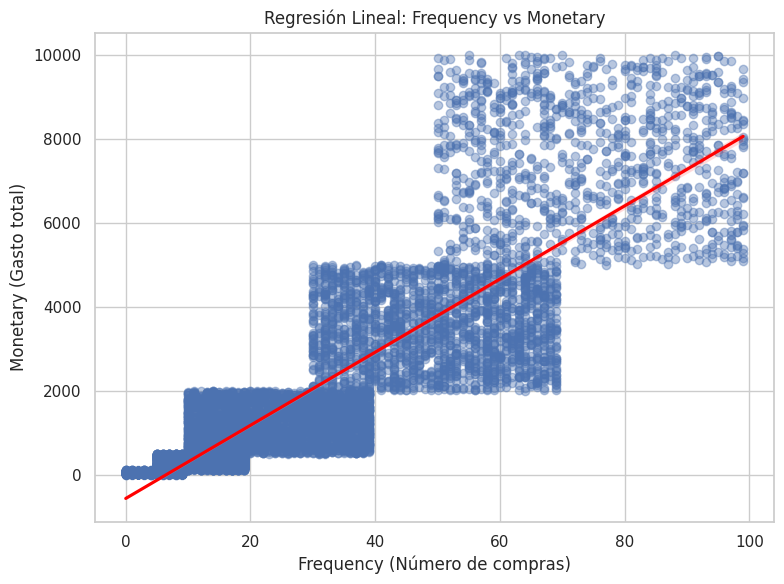

In [28]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='Frequency',
    y='Monetary',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)

plt.title('Regresión Lineal: Frequency vs Monetary')
plt.xlabel('Frequency (Número de compras)')
plt.ylabel('Monetary (Gasto total)')
plt.tight_layout()
plt.show()

La visualización confirma una relación lineal positiva entre Frequency y Monetary.
Se observa que a medida que aumenta el número de compras, el gasto total tiende a incrementarse, lo que es consistente con el coeficiente estimado en el modelo OLS.

In [46]:
# =========================
# REGRESIÓN LINEAL MÚLTIPLE: Monetary ~ Frequency + Session_Count + Clicks
# =========================

# Aplicar modelos con statsmodels

# Variable dependiente
y = df["Monetary"]

# Variables independientes (predictores)
X_multi = df[["Frequency", "Session_Count", "Clicks"]]

# Agregar intercepto (constante)
X_multi = sm.add_constant(X_multi)

# Ajustar el modelo
modelo_multiple = sm.OLS(y, X_multi).fit()

# Resumen del modelo
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:               Monetary   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                 1.864e+04
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:03:24   Log-Likelihood:                -82285.
No. Observations:               10000   AIC:                         1.646e+05
Df Residuals:                    9996   BIC:                         1.646e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -828.8123     14.945    -55.458

In [47]:
# Predicciones del modelo
y_pred_multi = modelo_multiple.predict(X_multi)

# Métricas
# R²
r2_multi = modelo_multiple.rsquared
r2_adj_multi = modelo_multiple.rsquared_adj

# MSE y MAE
mse_multi = np.mean((y - y_pred_multi) ** 2)
mae_multi = np.mean(np.abs(y - y_pred_multi))

print("\nMétricas del modelo múltiple:")
print(" R²:", round(r2_multi, 4))
print(" R² ajustado:", round(r2_adj_multi, 4))
print(" MSE:", round(mse_multi, 4))
print(" MAE:", round(mae_multi, 4))


Métricas del modelo múltiple:
 R²: 0.8484
 R² ajustado: 0.8483
 MSE: 821647.1514
 MAE: 628.4221


In [41]:
# Evaluar significancia de predictores (p-values)
# Tabla de p-values por predictor
pvals = modelo_multiple.pvalues.sort_values()
print("\nSignificancia de predictores (p-values):")
print(pvals)

# Identificar predictores significativos con alpha = 0.05
alpha = 0.05
significativos = pvals[pvals < alpha]
no_significativos = pvals[pvals >= alpha]

print("\nPredictores significativos (p < 0.05):")
print(significativos)

print("\nPredictores NO significativos (p >= 0.05):")
print(no_significativos)


Significancia de predictores (p-values):
const             0.000000e+00
Session_Count     0.000000e+00
Clicks           2.057668e-273
Frequency        2.134428e-205
dtype: float64

Predictores significativos (p < 0.05):
const             0.000000e+00
Session_Count     0.000000e+00
Clicks           2.057668e-273
Frequency        2.134428e-205
dtype: float64

Predictores NO significativos (p >= 0.05):
Series([], dtype: float64)


In [42]:
coef = modelo_multiple.params
print("\nInterpretación básica (modelo múltiple):")
print(f"- Intercepto (const): {coef['const']:.2f}")
print(f"- Frequency: {coef['Frequency']:.2f} -> Por cada compra adicional, Monetary cambia en {coef['Frequency']:.2f} USD, manteniendo Session_Count y Clicks constantes.")
print(f"- Session_Count: {coef['Session_Count']:.2f} -> Por cada sesión adicional, Monetary cambia en {coef['Session_Count']:.2f} USD, manteniendo las demás constantes.")
print(f"- Clicks: {coef['Clicks']:.2f} -> Por cada click adicional, Monetary cambia en {coef['Clicks']:.2f} USD, manteniendo las demás constantes.")


Interpretación básica (modelo múltiple):
- Intercepto (const): -828.81
- Frequency: 26.57 -> Por cada compra adicional, Monetary cambia en 26.57 USD, manteniendo Session_Count y Clicks constantes.
- Session_Count: 21.45 -> Por cada sesión adicional, Monetary cambia en 21.45 USD, manteniendo las demás constantes.
- Clicks: 0.66 -> Por cada click adicional, Monetary cambia en 0.66 USD, manteniendo las demás constantes.


## **Lección 5 - *Análisis Visual de Datos***

📌 Objetivo: Representar relaciones complejas y distribuciones
mediante Seaborn.

1. Crear gráficos de tipo pairplot, violinplot, jointplot y
heatmap

In [29]:
# Preparación (estilo + columnas)
sns.set_theme(style="whitegrid")  # estilo general

num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_col = "Segment_Label"

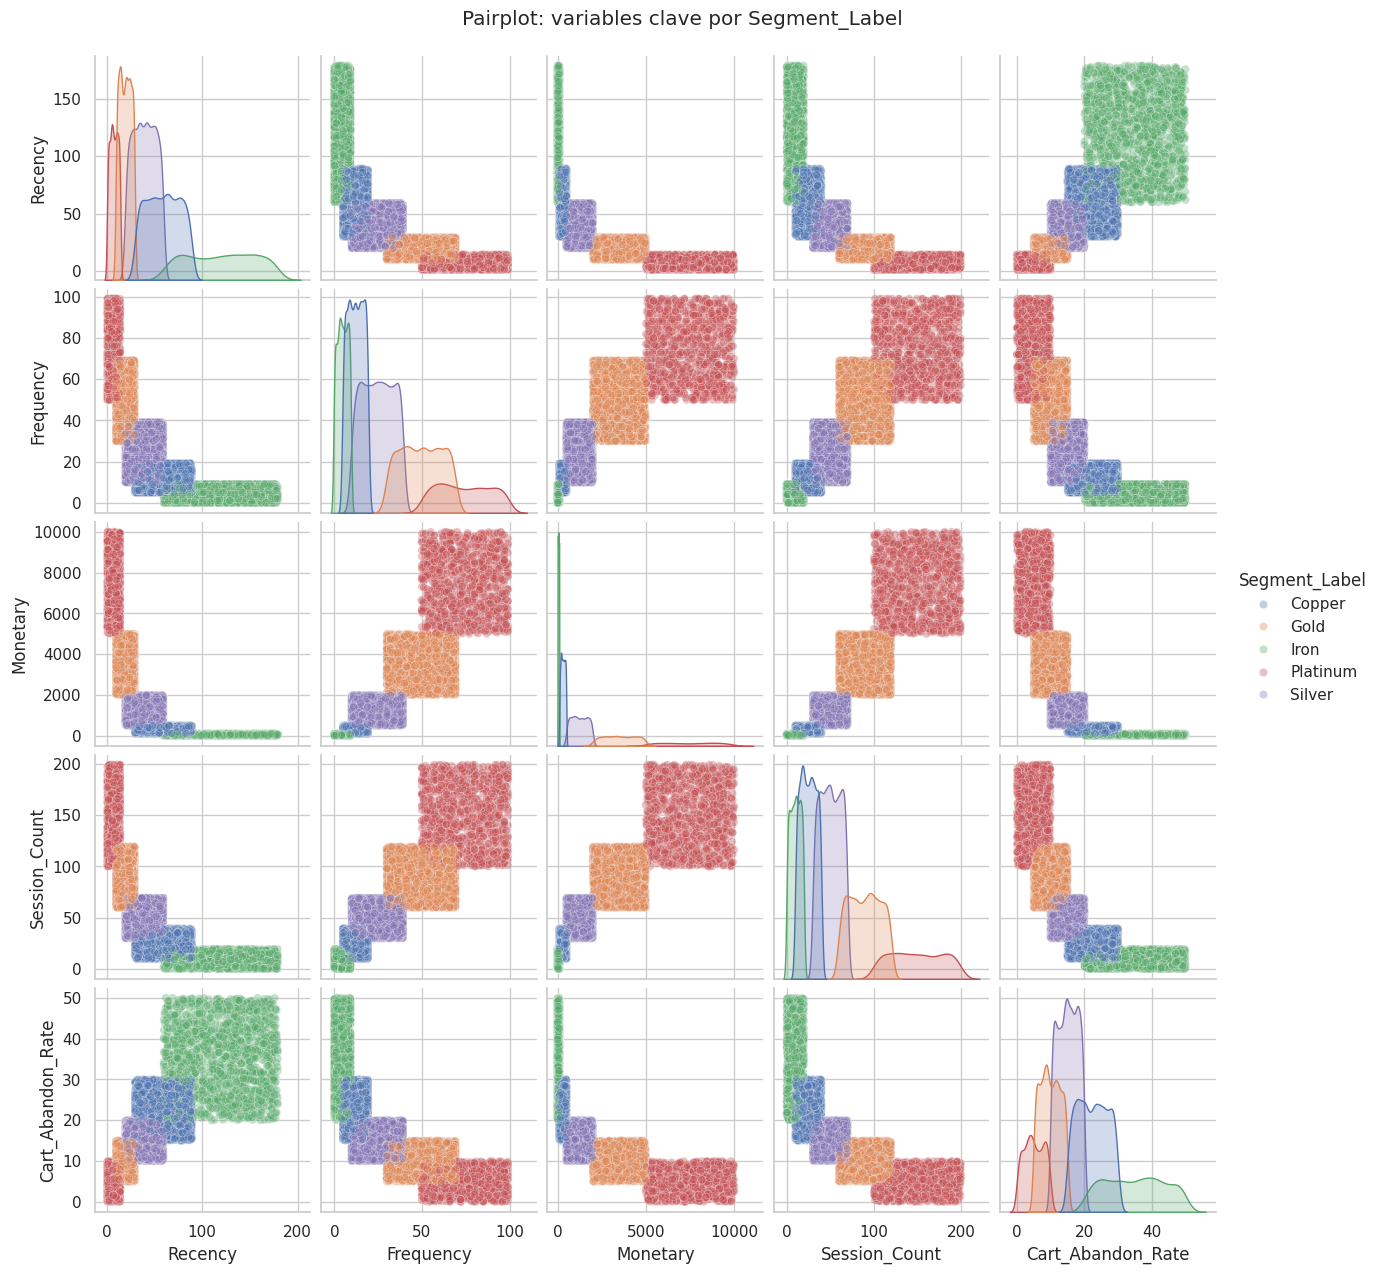

In [31]:
# Pairplot (relaciones múltiples + segmentación por categoría)
vars_pair = ["Recency", "Frequency", "Monetary", "Session_Count", "Cart_Abandon_Rate"]

sns.pairplot(
    df,
    vars=vars_pair,
    hue=cat_col,
    diag_kind="kde",
    plot_kws={"alpha": 0.35}
)
plt.suptitle("Pairplot: variables clave por Segment_Label", y=1.02)
plt.show()

La segmentación por Segment_Label muestra patrones diferenciados: segmentos superiores tienden a concentrarse en valores altos de Frequency y Monetary.

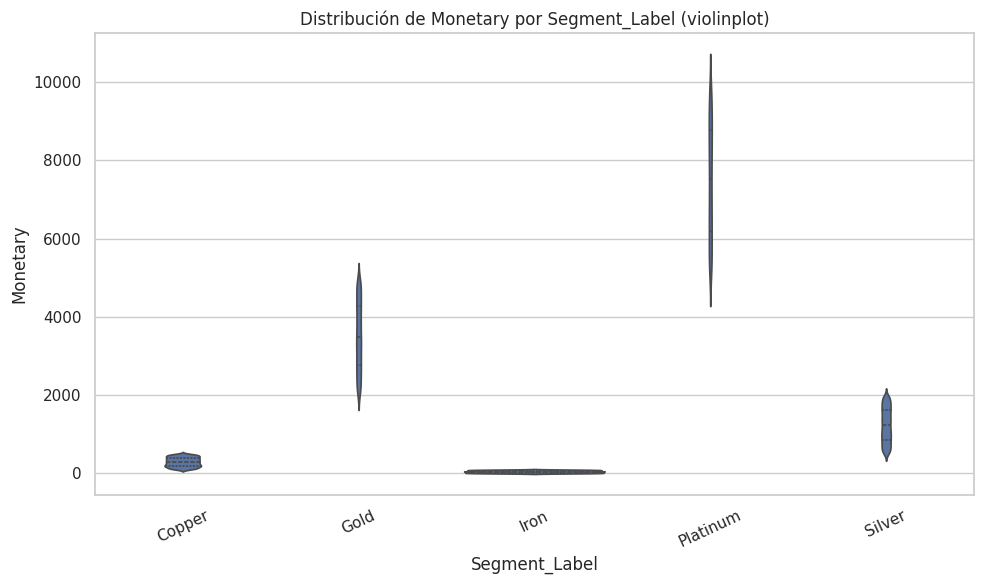

In [32]:
# Violinplot (distribuciones por segmento) - Monetary por segmento.
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x=cat_col, y="Monetary", inner="quartile")
plt.title("Distribución de Monetary por Segment_Label (violinplot)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

La distribución de Monetary cambia por segmento: los segmentos Platinum/Gold presentan medianas más altas y mayor dispersión, reflejando distintos niveles de gasto.

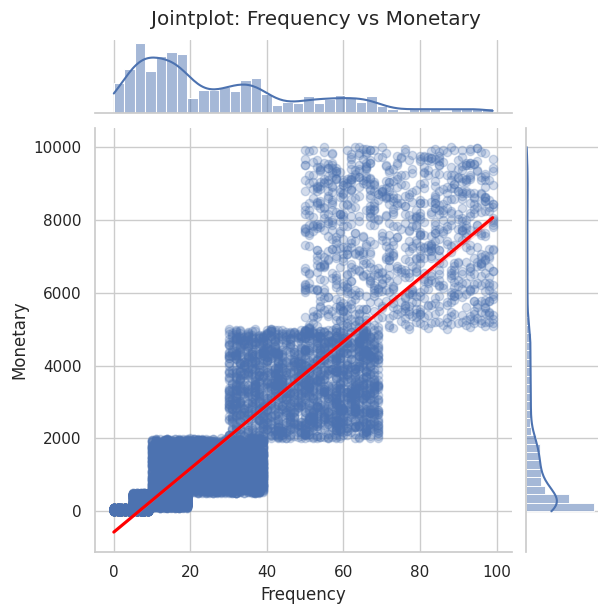

In [33]:
# Jointplot (relación 2 variables + distribución marginal) - Frequency vs Monetary.
sns.jointplot(
    data=df,
    x="Frequency",
    y="Monetary",
    kind="reg",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"}
)
plt.suptitle("Jointplot: Frequency vs Monetary", y=1.02)
plt.show()

La relación entre Frequency y Monetary es claramente positiva y aproximadamente lineal, reforzando el uso de modelos lineales para explicar el gasto total.

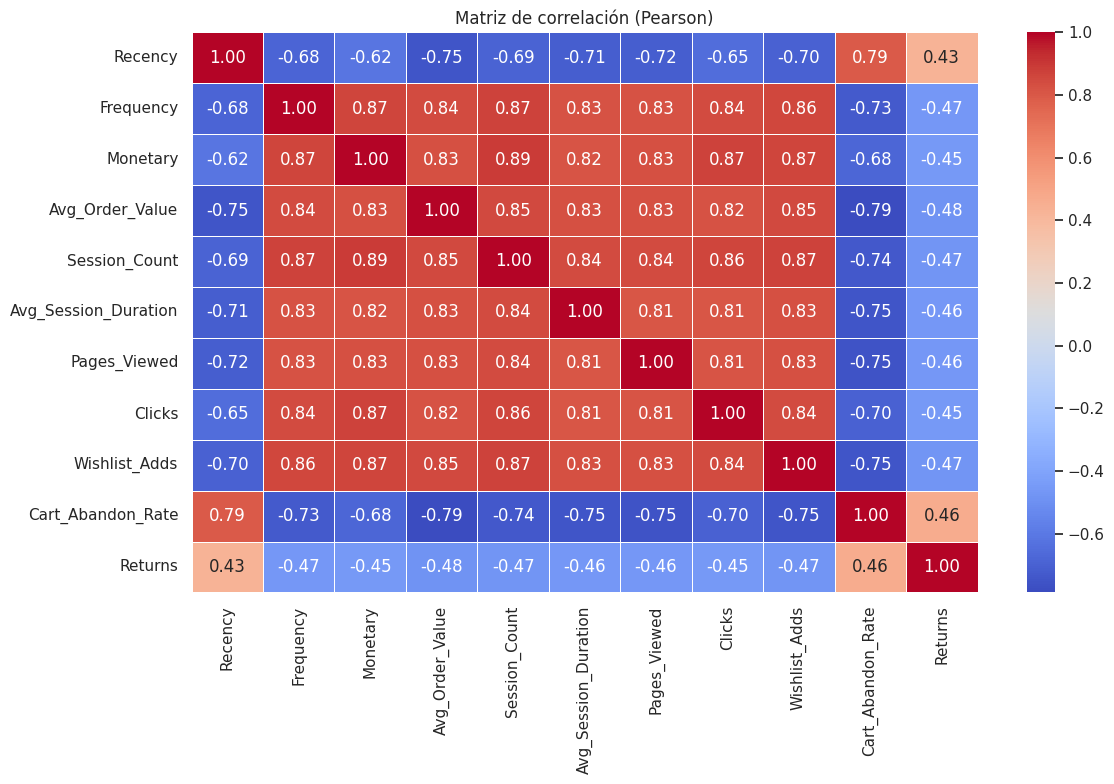

In [ ]:
# Heatmap (correlación, pero con mejor estilo)
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

Se observan correlaciones fuertes entre variables de comportamiento de compra (Frequency, Monetary) y métricas de interacción (Session_Count, Clicks), lo que sugiere que clientes más activos tienden a gastar más.

2. Construir visualizaciones que combinen múltiples variables

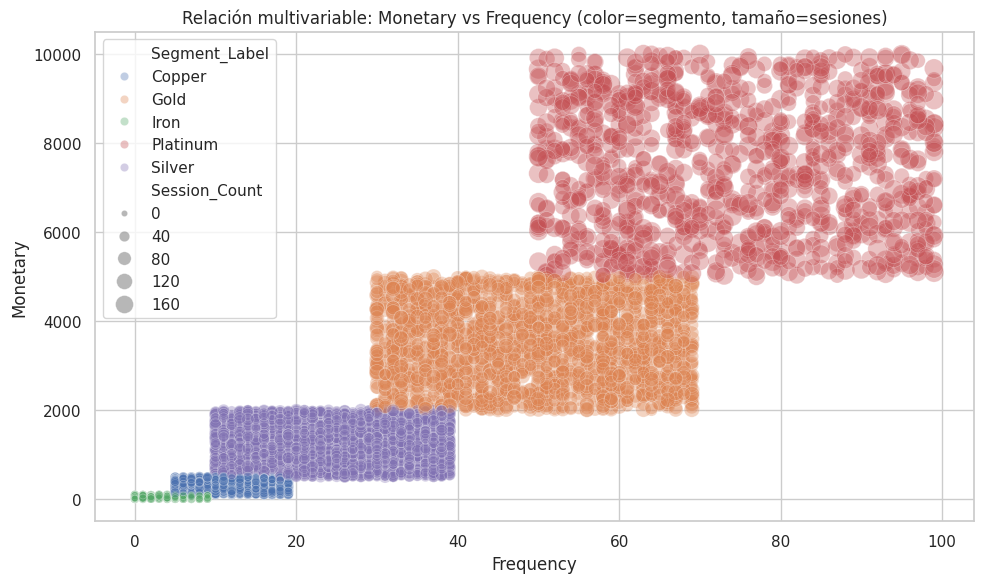

In [34]:
# Visualización multivariable (color + tamaño)
# Relación compleja con 3–4 variables:
# x: Frequency
#	y: Monetary
#	color: Segment_Label
#	tamaño: Session_Count

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Frequency",
    y="Monetary",
    hue=cat_col,
    size="Session_Count",
    sizes=(20, 200),
    alpha=0.35
)
plt.title("Relación multivariable: Monetary vs Frequency (color=segmento, tamaño=sesiones)")
plt.tight_layout()
plt.show()

Se observa que a mayor Frequency aumenta Monetary, y los segmentos superiores concentran valores mayores; además, a mayor Session_Count (puntos más grandes) tiende a observarse mayor gasto.

3. **Utilizar FacetGrid para segmentar por categorías**

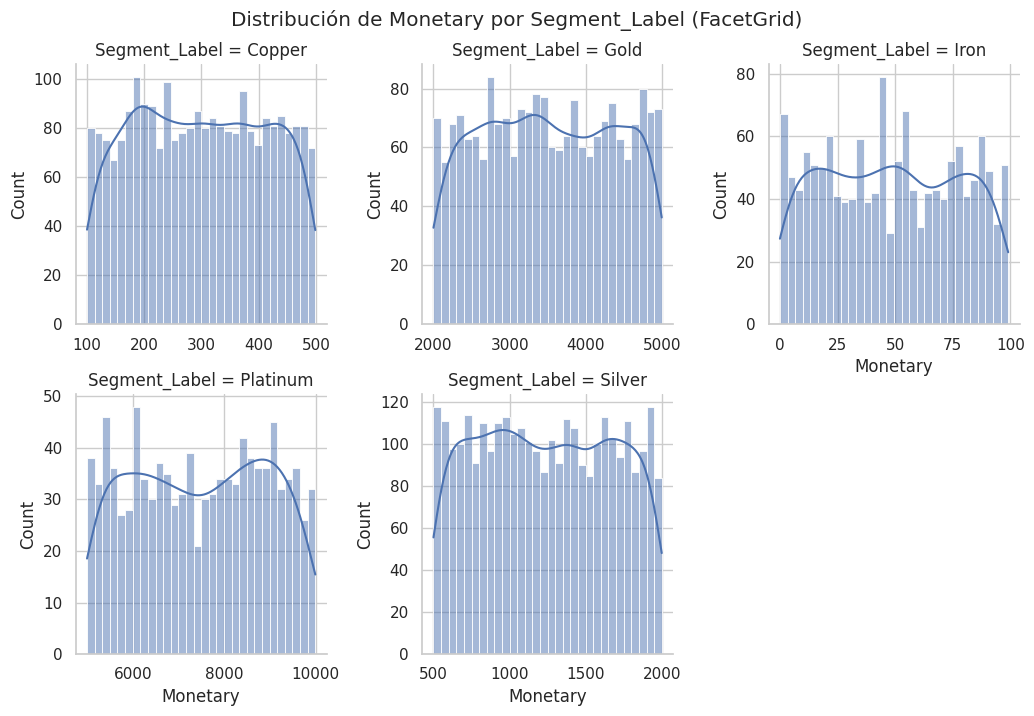

In [35]:
# FacetGrid (segmentar por categorías)
# Distribución de Monetary por segmento en paneles separados
g = sns.FacetGrid(df, col=cat_col, col_wrap=3, height=3.5, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="Monetary", bins=30, kde=True)
g.fig.suptitle("Distribución de Monetary por Segment_Label (FacetGrid)", y=1.02)
plt.show()

Al separar por segmentos, las distribuciones y relaciones mantienen patrones similares, pero con distintos rangos, evidenciando diferencias conductuales por grupo.

## **Lección 6 - *Libreria Matplotlib***

📌 Objetivo: Crear visualizaciones personalizadas y exportables.

1. Crear FIGURAS + SUBPLOTS
2. Personalizar títulos, etiquetas, leyendas, ticks.

Incluye: histograma, boxplot por segmento, scatter con línea y correlación simple.

/tmp/ipython-input-2593150833.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_seg, labels=segments, showfliers=False)
/tmp/ipython-input-2593150833.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(cat_col)["Monetary"].mean().reindex(segments)


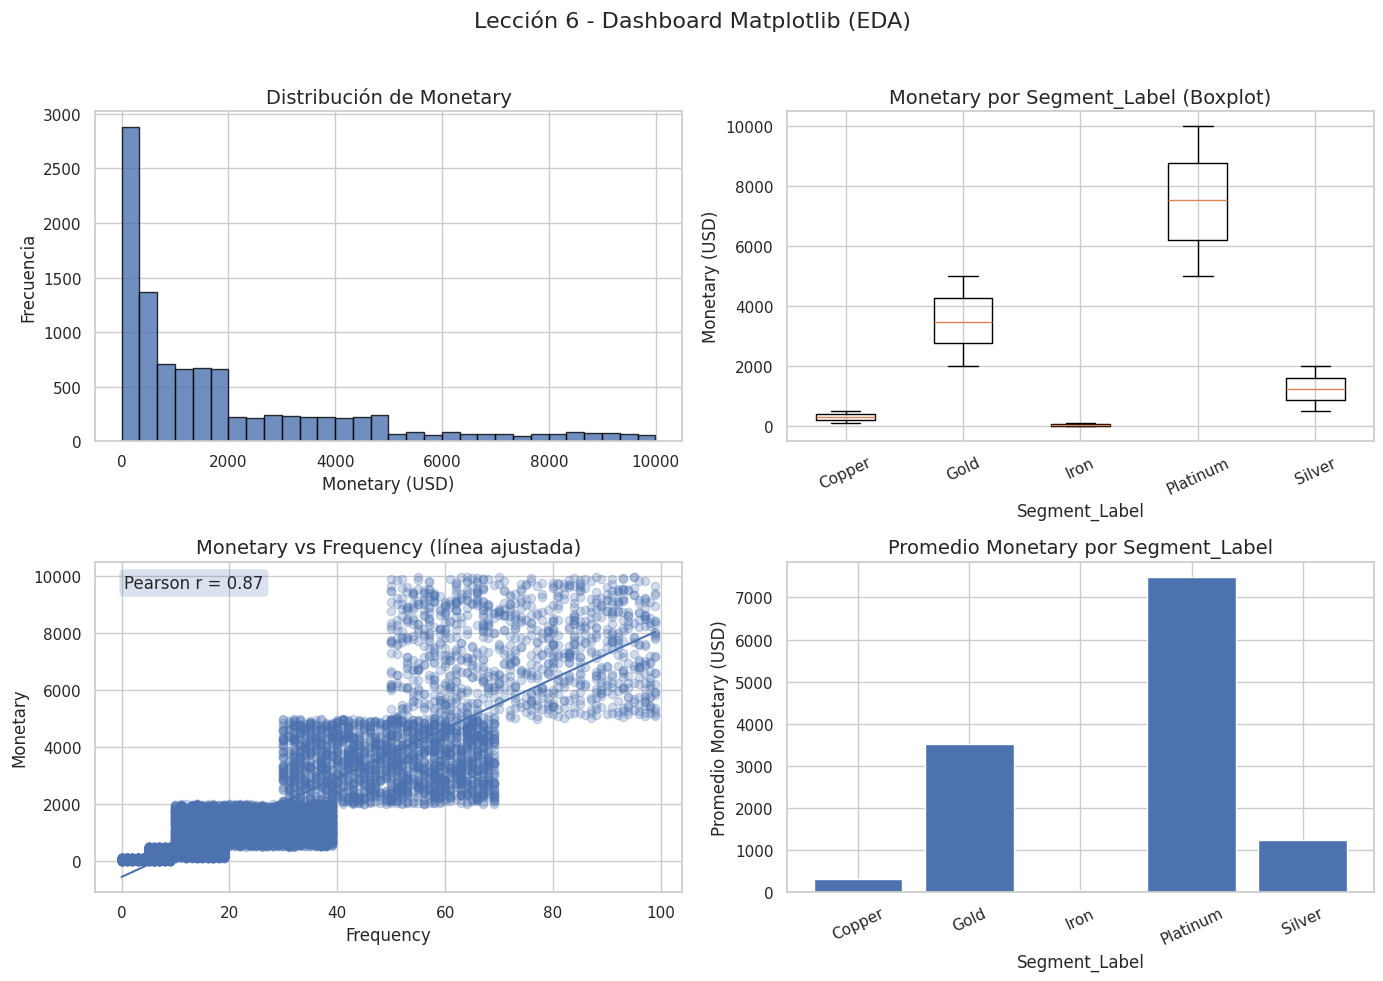

In [36]:
# Variables clave
x_var, y_var = "Frequency", "Monetary"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# --- (1) Histograma Monetary ---
ax1.hist(df["Monetary"], bins=30, edgecolor="black", alpha=0.8)
ax1.set_title("Distribución de Monetary", fontsize=14)
ax1.set_xlabel("Monetary (USD)")
ax1.set_ylabel("Frecuencia")

# --- (2) Boxplot Monetary por Segmento ---
segments = sorted(df[cat_col].unique())
data_by_seg = [df.loc[df[cat_col] == s, "Monetary"] for s in segments]
ax2.boxplot(data_by_seg, labels=segments, showfliers=False)
ax2.set_title("Monetary por Segment_Label (Boxplot)", fontsize=14)
ax2.set_xlabel("Segment_Label")
ax2.set_ylabel("Monetary (USD)")
ax2.tick_params(axis="x", rotation=25)

# --- (3) Scatter Frequency vs Monetary + línea (regresión simple con polyfit) ---
ax3.scatter(df[x_var], df[y_var], alpha=0.25)
m, b = np.polyfit(df[x_var], df[y_var], 1)
x_line = np.linspace(df[x_var].min(), df[x_var].max(), 100)
ax3.plot(x_line, m*x_line + b)
ax3.set_title(f"{y_var} vs {x_var} (línea ajustada)", fontsize=14)
ax3.set_xlabel(x_var)
ax3.set_ylabel(y_var)

# Anotación: correlación Pearson
r = np.corrcoef(df[x_var], df[y_var])[0, 1]
ax3.annotate(f"Pearson r = {r:.2f}", xy=(0.05, 0.92), xycoords="axes fraction",
             fontsize=12, bbox=dict(boxstyle="round", alpha=0.2))

# --- (4) Promedio de Monetary por segmento (bar) ---
means = df.groupby(cat_col)["Monetary"].mean().reindex(segments)
ax4.bar(means.index, means.values)
ax4.set_title("Promedio Monetary por Segment_Label", fontsize=14)
ax4.set_xlabel("Segment_Label")
ax4.set_ylabel("Promedio Monetary (USD)")
ax4.tick_params(axis="x", rotation=25)

# Ajustes finales del dashboard
fig.suptitle("Lección 6 - Dashboard Matplotlib (EDA)", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])

# Exportar (PNG y PDF)
fig.savefig(("dashboard_eda.png"), dpi=200, bbox_inches="tight")
fig.savefig(("dashboard_eda.pdf"), bbox_inches="tight")
plt.show()

3) Personalización extra: límites, ticks y formato numérico

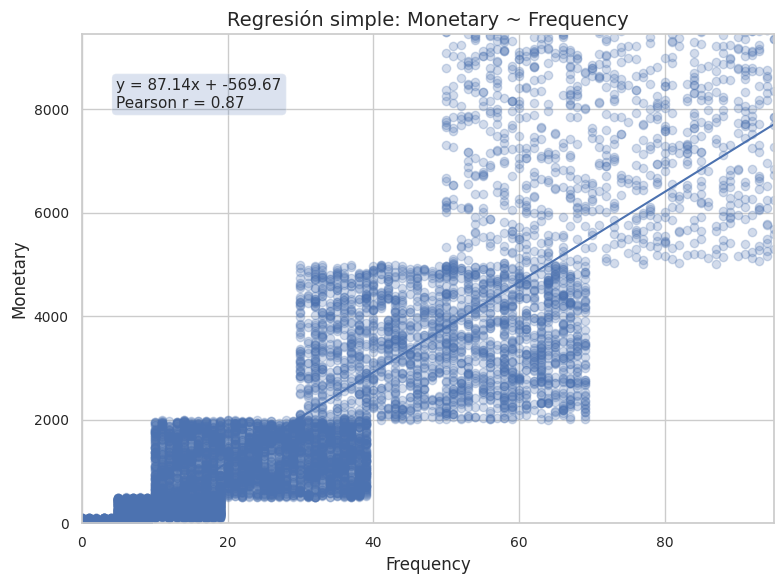

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df[x_var], df[y_var], alpha=0.25)
ax.plot(x_line, m*x_line + b)

ax.set_title(f"Regresión simple: {y_var} ~ {x_var}", fontsize=14)
ax.set_xlabel(x_var)
ax.set_ylabel(y_var)

# Límites (ajusta si quieres)
ax.set_xlim(0, df[x_var].quantile(0.99))
ax.set_ylim(0, df[y_var].quantile(0.99))

# Ticks más “limpios”
ax.tick_params(axis="both", labelsize=10)

# Anotación del modelo
ax.annotate(f"y = {m:.2f}x + {b:.2f}\nPearson r = {r:.2f}",
            xy=(0.05, 0.85), xycoords="axes fraction",
            fontsize=11, bbox=dict(boxstyle="round", alpha=0.2))

fig.tight_layout()
fig.savefig(("regresion_matplotlib.png"), dpi=200, bbox_inches="tight")
plt.show()